# Object Detection using YOLO on X-Ray Images of Luggage

Imports

In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00


In [ ]:
import kagglehub
import os
import numpy as np

import matplotlib.pyplot as plt
import cv2
import time

import yaml
import shutil


from ultralytics import YOLO
from IPython.display import Image as DisplayImage

In [ ]:
# download the dataset
path = kagglehub.dataset_download("orvile/x-ray-baggage-anomaly-detection")

print("Path to dataset files:", path)

100%|██████████| 133M/133M [00:04<00:00, 29.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1


## Dataset Exploration

In [ ]:
# check the contents of the path
print("Contents of dataset path:", os.listdir(path))

Contents of dataset path: ['train', 'data.yaml', 'valid', 'test', 'README.roboflow.txt', 'README.dataset.txt']


In [ ]:
# set train, validation and test paths
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "valid")
test_path = os.path.join(path, "test")

# show the contents of the train path
print("Contents of train path:", os.listdir(train_path))

Contents of train path: ['labels', 'images']


In [ ]:
# show the contents of the images and labels folders in the train path
print("Contents of train images path:", os.listdir(os.path.join(train_path, "images"))[:3])
print("Contents of train labels path:", os.listdir(os.path.join(train_path, "labels"))[:3])

# print number of images and labels in the train path
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_train_labels = len(os.listdir(os.path.join(train_path, "labels")))
print(f"Number of training images: {num_train_images}")
print(f"Number of training labels: {num_train_labels}")

Contents of train images path: ['027053_jpg.rf.fc884ef604939cde22cda0cd61d1d149.jpg', '009880_jpg.rf.ad0fd0cd760ee9ba7c74b0f1d58cd34b.jpg', '010627_jpg.rf.8adabc2917556c34f0c86b05f245439c.jpg']
Contents of train labels path: ['041258_jpg.rf.841f7caec65f73c8d8c6662c192e9f44.txt', '036564_jpg.rf.f079fe044d332157ec69dd5f32fa5a0a.txt', '042787_jpg.rf.d3f902e6a91da1d547f070032d520eab.txt']
Number of training images: 6181
Number of training labels: 6181


Each image has a corresponding txt file with the same name in the labels folder. Lets inspect one of the images and its corresponding label file.

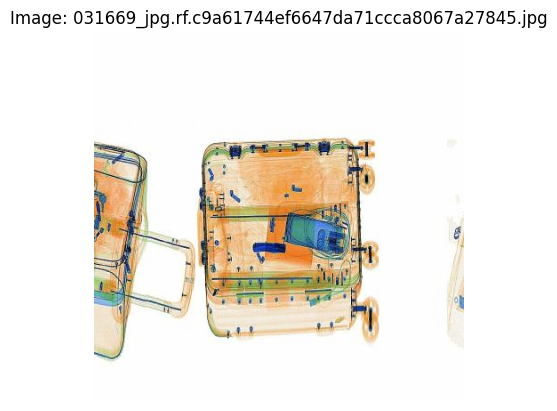

Contents of label file 031669_jpg.rf.c9a61744ef6647da71ccca8067a27845.txt:
1 0.47716346153846156 0.5853365384615384 0.1045673076923077 0.037259615384615384


In [ ]:
# select an image and its corresponding label file
image_file = os.listdir(os.path.join(train_path, "images"))[20]
label_file = image_file.replace(".jpg", ".txt")

# read the image
image = cv2.imread(os.path.join(train_path, "images", image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# read the label file
with open(os.path.join(train_path, "labels", label_file), "r") as f:
    label_contents = f.read()

# plot the image
plt.imshow(image)
plt.title(f"Image: {image_file}")
plt.axis("off")
plt.show()

# print the contents
print(f"Contents of label file {label_file}:\n{label_contents}")

Each label file contains 4 numbers corresponding to:
- class id
- center x coordinate of the bounding box (normalized by image width)
- center y coordinate of the bounding box (normalized by image height)
- width of the bounding box (normalized by image width)
- height of the bounding box (normalized by image height)

Let's visualize the bounding box on top of the image to better understand the format of the label files.

In [ ]:
def draw_yolo_bbox(image_path, label_data):
    img = cv2.imread(image_path)
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _ = img.shape

    for line in label_data.splitlines():
        # extract data from label
        _, x, y, w, h = map(float, line.split())
        print(f"Label data - x: {x}, y: {y}, w: {w}, h: {h}")

        # convert normalized coordinates to pixel values
        center_x, center_y = int(x * W), int(y * H)
        width, height = int(w * W), int(h * H)

        # compute top-left and bottom-right corners of the bounding box
        xmin = int(center_x - (width / 2))
        ymin = int(center_y - (height / 2))
        xmax = int(center_x + (width / 2))
        ymax = int(center_y + (height / 2))

        # plot on top of the image (rectangle in red)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Objetos Prohibidos Detectados")
    plt.axis('off')
    plt.show()

Label data - x: 0.47716346153846156, y: 0.5853365384615384, w: 0.1045673076923077, h: 0.037259615384615384


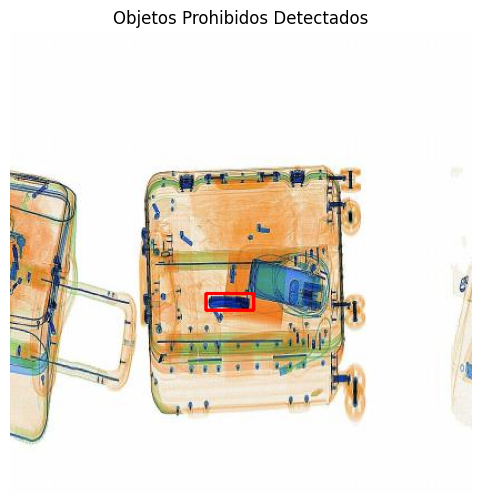

In [ ]:
draw_yolo_bbox(os.path.join(train_path, "images", image_file), label_contents)

In [ ]:
# count the number of images in each set
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_val_images = len(os.listdir(os.path.join(val_path, "images")))
num_test_images = len(os.listdir(os.path.join(test_path, "images")))

print(f"Number of training images: {num_train_images}")
print(f"Number of validation images: {num_val_images}")
print(f"Number of test images: {num_test_images}")

Number of training images: 6181
Number of validation images: 1766
Number of test images: 883


In [ ]:
# average number of objects per image in each set
def average_objects_per_image(label_path):
    total_objects = 0
    total_images = 0

    for label_file in os.listdir(label_path):
        with open(os.path.join(label_path, label_file), "r") as f:
            lines = f.readlines()
            total_objects += len(lines)
            total_images += 1

    return total_objects / total_images if total_images > 0 else 0

avg_objects_train = average_objects_per_image(os.path.join(train_path, "labels"))
avg_objects_val = average_objects_per_image(os.path.join(val_path, "labels"))
avg_objects_test = average_objects_per_image(os.path.join(test_path, "labels"))

print(f"Average number of objects per image in training set: {avg_objects_train:.2f}")
print(f"Average number of objects per image in validation set: {avg_objects_val:.2f}")
print(f"Average number of objects per image in test set: {avg_objects_test:.2f}")

Average number of objects per image in training set: 1.00
Average number of objects per image in validation set: 1.00
Average number of objects per image in test set: 1.00


In [ ]:
# mean and std dev of image dimensions in each set
def average_image_dimensions(image_path):
    widths = []
    heights = []

    for image_file in os.listdir(image_path):
        img = cv2.imread(os.path.join(image_path, image_file))
        if img is not None:
            h, w, _ = img.shape
            widths.append(w)
            heights.append(h)

    if not widths:
        return 0, 0, 0, 0

    # compute mean values
    avg_width = np.mean(widths)
    avg_height = np.mean(heights)

    # compute standard deviation values
    std_width = np.std(widths)
    std_height = np.std(heights)

    return avg_width, avg_height, std_width, std_height

In [ ]:
avg_w_train, avg_h_train, std_w_train, std_h_train = average_image_dimensions(os.path.join(train_path, "images"))
avg_w_val, avg_h_val, std_w_val, std_h_val = average_image_dimensions(os.path.join(val_path, "images"))
avg_w_test, avg_h_test, std_w_test, std_h_test = average_image_dimensions(os.path.join(test_path, "images"))

print(f"Training set - Average width: {avg_w_train:.2f}, Average height: {avg_h_train:.2f}, Std width: {std_w_train:.2f}, Std height: {std_h_train:.2f}")
print(f"Validation set - Average width: {avg_w_val:.2f}, Average height: {avg_h_val:.2f}, Std width: {std_w_val:.2f}, Std height: {std_h_val:.2f}")
print(f"Test set - Average width: {avg_w_test:.2f}, Average height: {avg_h_test:.2f}, Std width: {std_w_test:.2f}, Std height: {std_h_test:.2f}")

Training set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00
Validation set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00
Test set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00


All images are sized 416x416 pixels and have at most one proihibited item.

## Image Preprocessing

In [ ]:
def preprocess_xray(img):
    # use CLAHE to enhance contrast
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # then apply a bilateral filter to smooth noise while keeping edges as sharp as possible
    filtered = cv2.bilateralFilter(img_clahe, d=9, sigmaColor=75, sigmaSpace=75)

    # highlight edges using morphological gradient - enhances objects
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    gradient = cv2.morphologyEx(filtered, cv2.MORPH_GRADIENT, kernel)

    # combine the filtered image with the edges - give 90% weight to the clean image and 10% to the pure edges
    img_final = cv2.addWeighted(filtered, 0.9, gradient, 0.1, 0)

    return img_final

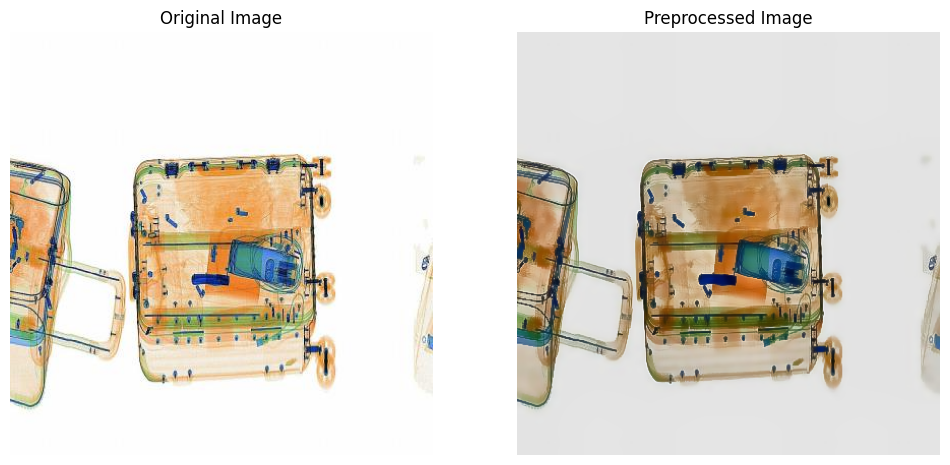

In [ ]:
# plot original and preprocessed image side by side
original_img = cv2.imread(os.path.join(train_path, "images", image_file))
preprocessed_img = preprocess_xray(original_img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(preprocessed_img, cv2.COLOR_BGR2RGB))
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

In [ ]:
path

'/root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1'

Apply the preprocessing function to all images in every dataset split.

In [ ]:
def apply_preprocessing_to_folder(src_path, dest_path):
    os.makedirs(dest_path, exist_ok=True)
    for img_name in os.listdir(src_path):
        img = cv2.imread(os.path.join(src_path, img_name))
        if img is not None:
            processed = preprocess_xray(img)
            cv2.imwrite(os.path.join(dest_path, img_name), processed)

# apply to train, val and test
output_path = "/content/x-ray-baggage-anomaly-detection_processed"

train_images_proc = os.path.join(output_path, "train_processed", "images")
val_images_proc = os.path.join(output_path, "valid_processed", "images")
test_images_proc = os.path.join(output_path, "test_processed", "images")

print("Preprocessing images")
start_time = time.time()
apply_preprocessing_to_folder(os.path.join(train_path, "images"), train_images_proc)
apply_preprocessing_to_folder(os.path.join(val_path, "images"), val_images_proc)
apply_preprocessing_to_folder(os.path.join(test_path, "images"), test_images_proc)
end_time = time.time()
print(f"Preprocessing completed in {end_time - start_time:.2f} seconds")

Preprocessing images
Preprocessing completed in 352.08 seconds


## YOLOv11s Model Training

Configure the yaml file. This initial configuration takes the default values for all parameters except for the number of classes and the paths to the training and validation datasets. We will use the default hyperparameters for training, which are optimized for small datasets.

In [ ]:
data_config = {
    'train': train_images_proc.replace("/images", ""),
    'val': val_images_proc.replace("/images", ""),
    'test': test_images_proc.replace("/images", ""),
    'nc': 5,
    'names': ['0', '1', '2', '3', '4']
}

with open('xray_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

folder_mapping = {
    "train": "train_processed",
    "valid": "valid_processed",
    "test": "test_processed"
}

for orig_folder, dest_folder in folder_mapping.items():
    src_labels = os.path.join(path, orig_folder, "labels")
    dest_labels = os.path.join(output_path, dest_folder, "labels")
    shutil.copytree(src_labels, dest_labels, dirs_exist_ok=True)

In [ ]:
# load yolo model
model = YOLO('yolo11s.pt')

# train with data augmentation techniques
results = model.train(
    data='xray_data.yaml',
    epochs=50,
    imgsz=416,
    batch=16,
    name='yolo11_xray_results_v2',
    device="cuda",
    patience=10,
    hsv_h=0.015, # hue adjustment
    hsv_s=0.7, # saturation adjustment
    hsv_v=0.4, # brightness adjustment
    degrees=10.0, # random rotation
    translate=0.1, # translation
    scale=0.5, # scale
    flipud=0.0, # vertical flip
    fliplr=0.5, # horizontal flip
    mosaic=1.0 # mosaic technique
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=xray_data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_xray_results_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, 

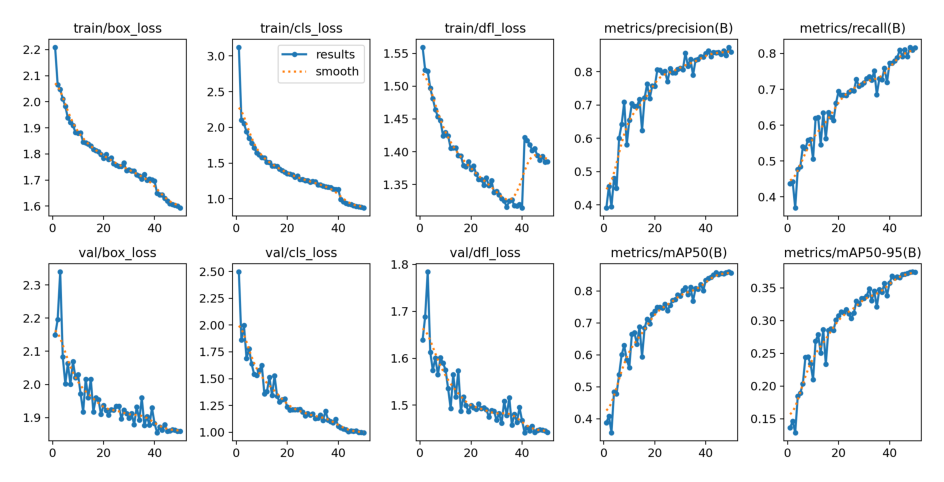

In [ ]:
# visualize training results
results_path = 'runs/detect/yolo11_xray_results_v2/'

plt.figure(figsize=(12, 6))
plt.imshow(plt.imread(os.path.join(results_path, 'results.png')))
plt.axis('off')
plt.show()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1340.6±572.6 MB/s, size: 32.2 KB)
val: Scanning /content/x-ray-baggage-anomaly-detection_processed/test_processed/labels.cache... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 336.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 6.5it/s 8.6s
                   all        883        883      0.879      0.844      0.894      0.415
                     0        166        166      0.976      0.988      0.985      0.504
                     1        193        193      0.873      0.855       0.91      0.415
                     2        118        118      0.762      0.653      0.759      0.305
                     3        203        203      0.889      0.823      0.881      0.417
                     4        203        203      0.897      0.901      0.936      0.

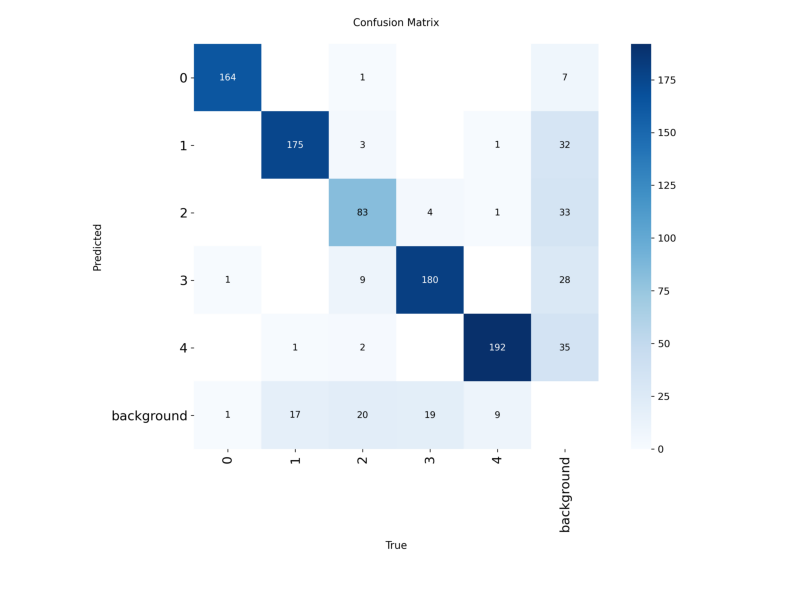


Métricas de detección de objetos
mAP50-95 (Global): 0.4150
mAP50 (Global):    0.8941
Precision (Mean):  0.8793
Recall (Mean):     0.8440

REPORTE DE CLASIFICACION POR CLASE:
Clase          ID    Precision   Recall      mAP50       mAP50-95    
---------------------------------------------------------------------
0              0     0.9763      0.9880      0.9850      0.5045      
1              1     0.8728      0.8549      0.9099      0.4150      
2              2     0.7624      0.6528      0.7588      0.3054      
3              3     0.8886      0.8227      0.8810      0.4170      
4              4     0.8965      0.9015      0.9357      0.4330      
---------------------------------------------------------------------


In [ ]:
# evaluate the model on the test set
metrics = model.val(data='xray_data.yaml', split='test')
test_results_path = metrics.save_dir

print(f"Test results saved in: {test_results_path}")

# visualize the confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(plt.imread(f'{test_results_path}/confusion_matrix.png'))
plt.axis('off')
plt.show()


print("\n" + "="*50)
print("Object Detection Metrics")
print("="*50)
print(f"mAP50-95 (Global): {metrics.box.map:.4f}")
print(f"mAP50 (Global):    {metrics.box.map50:.4f}")
print(f"Precision (Mean):  {metrics.box.mp:.4f}")
print(f"Recall (Mean):     {metrics.box.mr:.4f}")
print("="*50)

print("\nCLASSIFICATION REPORT BY CLASS:")
print(f"{'Class':<15}{'ID':<6}{'Precision':<12}{'Recall':<12}{'mAP50':<12}{'mAP50-95':<12}")
print("-" * 69)

# get the class names from the model for mapping
class_names = model.names

# iterate over each class evaluated in the box metrics
for i, class_idx in enumerate(metrics.box.ap_class_index):
    c_name = class_names[class_idx]

    # extract individual metrics for each class
    c_precision = metrics.box.p[i]
    c_recall = metrics.box.r[i]
    c_map50 = metrics.box.ap50[i]
    c_map55_95 = metrics.box.ap[i] # Average AP from IoU 0.50 to 0.95

    print(f"{c_name:<15}{class_idx:<6}{c_precision:<12.4f}{c_recall:<12.4f}{c_map50:<12.4f}{c_map55_95:<12.4f}")
print("-" * 69)

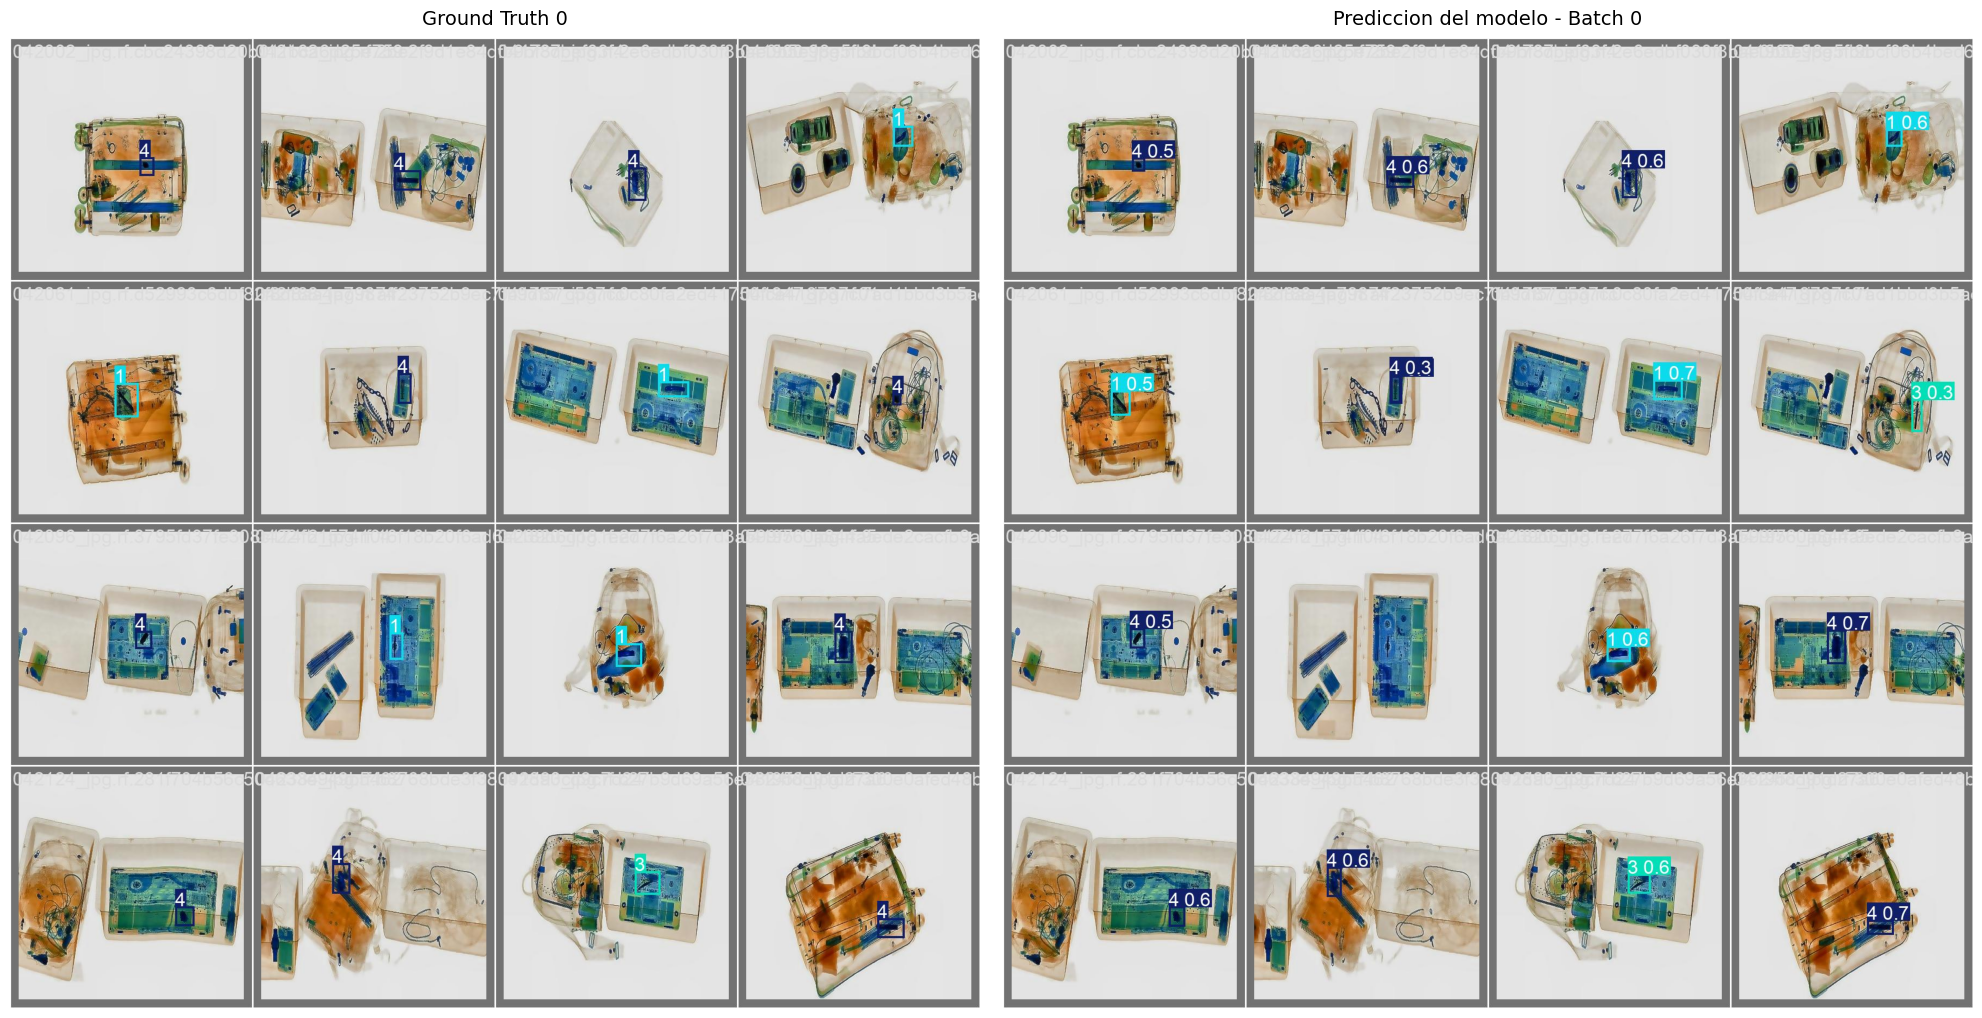

In [ ]:
# generate predictions for a batch to visualize
batch_num = 0
img_labels_path = os.path.join(test_results_path, f'val_batch{batch_num}_labels.jpg')
img_preds_path = os.path.join(test_results_path, f'val_batch{batch_num}_pred.jpg')

# validate that the images exist before trying to load them
if os.path.exists(img_labels_path) and os.path.exists(img_preds_path):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # load and display ground truth
    img_labels = plt.imread(img_labels_path)
    axes[0].imshow(img_labels)
    axes[0].set_title(f"Ground Truth {batch_num}", fontsize=14, pad=10)
    axes[0].axis('off')

    img_preds = plt.imread(img_preds_path)
    axes[1].imshow(img_preds)
    axes[1].set_title(f"Model Predictions - Batch {batch_num}", fontsize=14, pad=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No images found for batch {batch_num} in the results path.")

In [ ]:
# download the best model weights - using colab
from google.colab import files

best_model_path = 'runs/detect/yolo11_xray_results_v2/weights/best.pt'

if os.path.exists(best_model_path):
    files.download(best_model_path)
else:
    print(f"No file found at {best_model_path}.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Train the model modifying the data augmentation

In [ ]:
# load yolo model
model = YOLO('yolo11s.pt')

# Entrenamos
results = model.train(
    data='xray_data.yaml',
    epochs=50,
    imgsz=416,
    batch=16,
    name='yolo11_xray_results_v3',
    device="cuda",
    patience=10,
    degrees=20.0, # random rotation
    translate=0.1, # translation
    scale=0.5, # scale
    flipud=0.0, # vertical flip
    fliplr=0.5, # horizontal flip
    mosaic=1.0 # mosaic technique
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=xray_data.yaml, degrees=20.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_xray_results_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, 

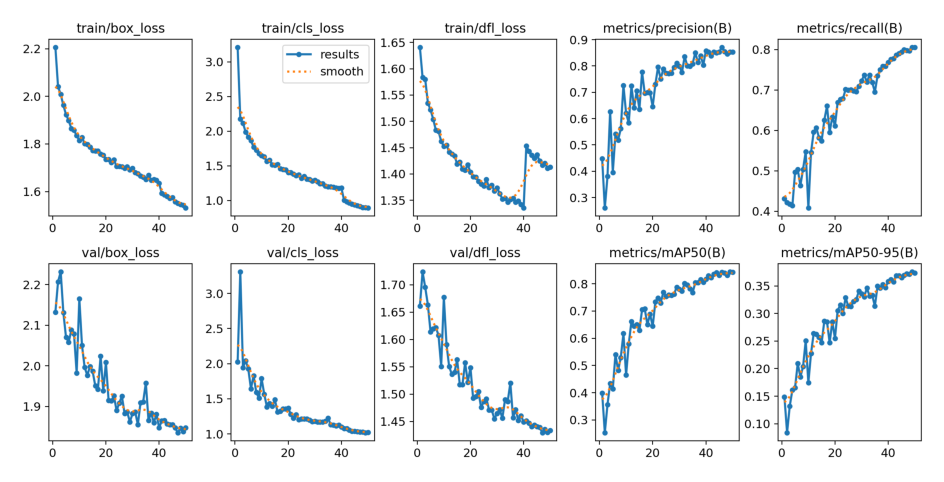

In [ ]:
# visualize training results
results_path = 'runs/detect/yolo11_xray_results_v3/'

plt.figure(figsize=(12, 6))
plt.imshow(plt.imread(os.path.join(results_path, 'results.png')))
plt.axis('off')
plt.show()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 753.2±217.3 MB/s, size: 25.6 KB)
val: Scanning /content/x-ray-baggage-anomaly-detection_processed/test_processed/labels.cache... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 308.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 3.7it/s 15.1s
                   all        883        883      0.911      0.807      0.881      0.408
                     0        166        166      0.995      0.982      0.985      0.514
                     1        193        193       0.89      0.798      0.893      0.411
                     2        118        118      0.821      0.585      0.712      0.276
                     3        203        203      0.891      0.813      0.877      0.409
 

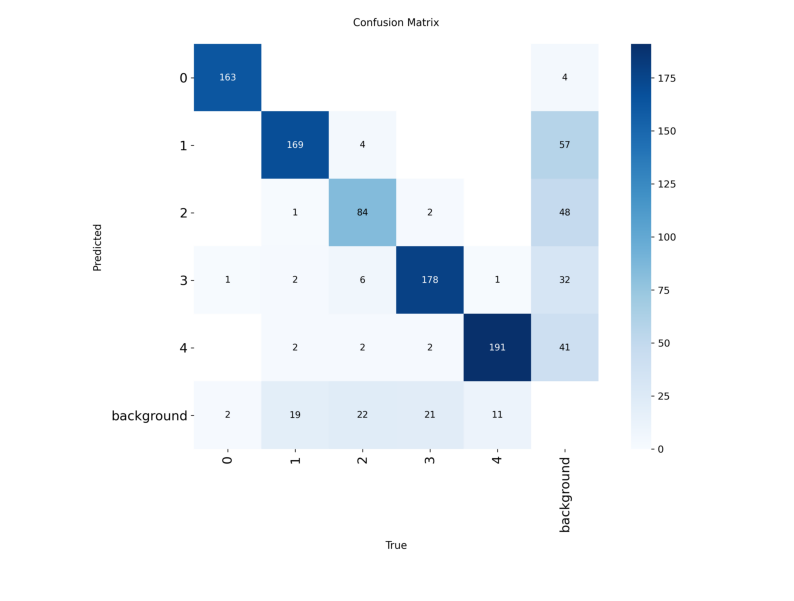


Métricas de detección de objetos
mAP50-95 (Global): 0.4077
mAP50 (Global):    0.8812
Precision (Mean):  0.9111
Recall (Mean):     0.8069

REPORTE DE CLASIFICACION POR CLASE:
Clase          ID    Precision   Recall      mAP50       mAP50-95    
---------------------------------------------------------------------
0              0     0.9952      0.9819      0.9850      0.5136      
1              1     0.8898      0.7979      0.8929      0.4111      
2              2     0.8215      0.5847      0.7125      0.2764      
3              3     0.8905      0.8128      0.8775      0.4087      
4              4     0.9584      0.8571      0.9380      0.4288      
---------------------------------------------------------------------


In [ ]:
# evaluate the model on the test set
metrics = model.val(data='xray_data.yaml', split='test')
test_results_path = metrics.save_dir

print(f"Test results saved in: {test_results_path}")

# visualize the confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(plt.imread(f'{test_results_path}/confusion_matrix.png'))
plt.axis('off')
plt.show()


print("\n" + "="*50)
print("Object Detection Metrics (Test Set)")
print("="*50)
print(f"mAP50-95 (Global): {metrics.box.map:.4f}")
print(f"mAP50 (Global):    {metrics.box.map50:.4f}")
print(f"Precision (Mean):  {metrics.box.mp:.4f}")
print(f"Recall (Mean):     {metrics.box.mr:.4f}")
print("="*50)

print("\nCLASSIFICATION REPORT BY CLASS:")
print(f"{'Class':<15}{'ID':<6}{'Precision':<12}{'Recall':<12}{'mAP50':<12}{'mAP50-95':<12}")
print("-" * 69)

# get the class names from the model for mapping
class_names = model.names

# iterate over each class evaluated in the box metrics
for i, class_idx in enumerate(metrics.box.ap_class_index):
    c_name = class_names[class_idx]

    # extract individual metrics per class
    c_precision = metrics.box.p[i]
    c_recall = metrics.box.r[i]
    c_map50 = metrics.box.ap50[i]
    c_map55_95 = metrics.box.ap[i] # Average AP from IoU 0.50 to 0.95

    print(f"{c_name:<15}{class_idx:<6}{c_precision:<12.4f}{c_recall:<12.4f}{c_map50:<12.4f}{c_map55_95:<12.4f}")
print("-" * 69)

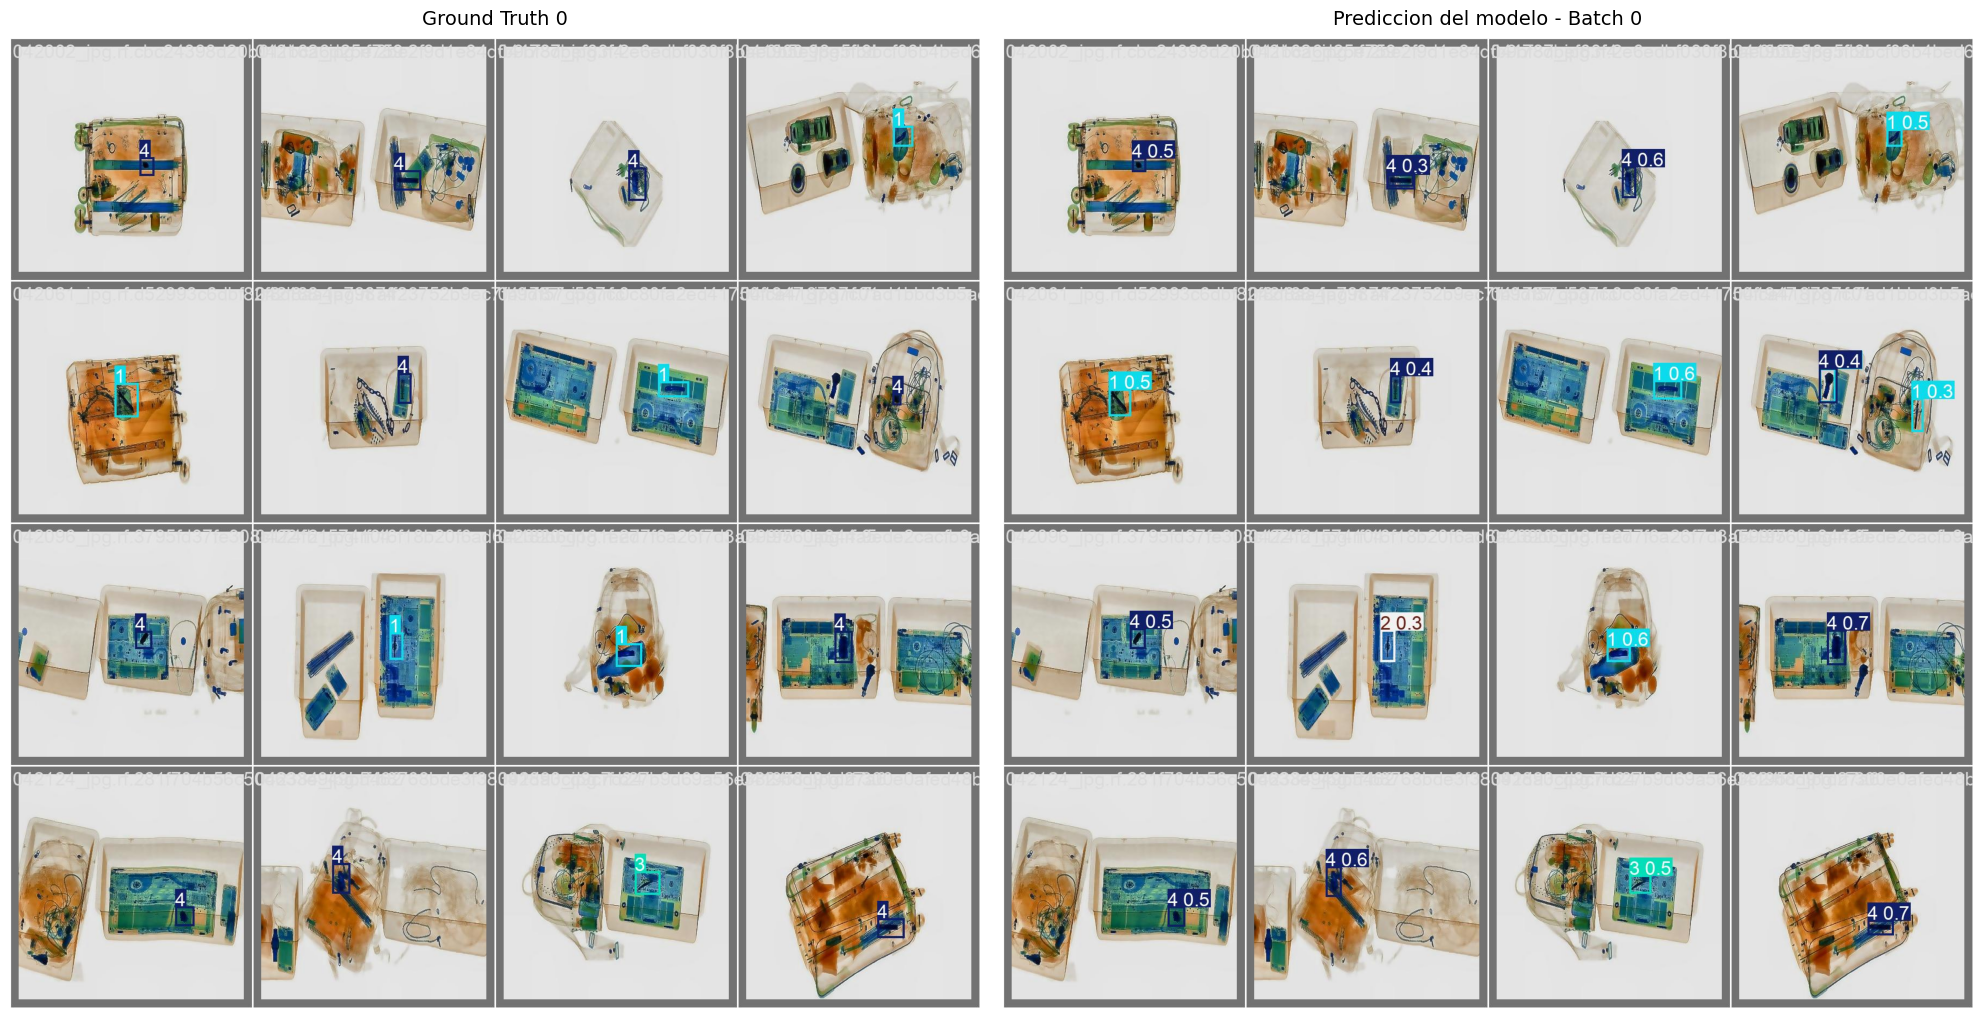

In [ ]:
# generate predictions for a batch to visualize
batch_num = 0
img_labels_path = os.path.join(test_results_path, f'val_batch{batch_num}_labels.jpg')
img_preds_path = os.path.join(test_results_path, f'val_batch{batch_num}_pred.jpg')

# validate that the files exist before trying to load them
if os.path.exists(img_labels_path) and os.path.exists(img_preds_path):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # load and display ground truth
    img_labels = plt.imread(img_labels_path)
    axes[0].imshow(img_labels)
    axes[0].set_title(f"Ground Truth {batch_num}", fontsize=14, pad=10)
    axes[0].axis('off')

    img_preds = plt.imread(img_preds_path)
    axes[1].imshow(img_preds)
    axes[1].set_title(f"Prediccion del modelo - Batch {batch_num}", fontsize=14, pad=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron las imágenes del batch {batch_num} en la ruta de resultados.")

In [ ]:
# download the best model weights - using colab
from google.colab import files

best_model_path = 'runs/detect/yolo11_xray_results_v3/weights/best.pt'

if os.path.exists(best_model_path):
    files.download(best_model_path)
else:
    print(f"File not found at {best_model_path}.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>